<a href="https://colab.research.google.com/github/nanduvarghese-glitch/gen-ai/blob/main/DAY5/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

from nltk.stem import WordNetLemmatizer

In [2]:
df=pd.read_csv('/content/bbc_news_text_complexity_summarization.csv')

In [3]:
df

,text,labels,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score,text_rank_summary,lsa_summary
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,26,62.17,9.72,It hopes to increase subscribers by offering t...,Its profits were buoyed by one-off gains which...
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,17,65.56,9.09,The dollar has hit its highest level against t...,"""I think the chairman's taking a much more san..."
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,14,69.21,9.66,The owners of embattled Russian oil giant Yuko...,Yukos' owner Menatep Group says it will ask Ro...
3,High fuel prices hit BA's profits\n\nBritish A...,business,24,62.98,9.86,Looking ahead to its full year results to Marc...,"Rod Eddington, BA's chief executive, said the ..."
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,17,70.63,10.23,Reports in the Wall Street Journal and the Fin...,Shares in UK drinks and food firm Allied Domec...
...,...,...,...,...,...,...,...
2122,New consoles promise big problems\n\nMaking ga...,tech,52,60.85,9.20,Instead of employing lots of artists to create...,Mr Wright said that enabling players to devise...
2123,BT program to beat dialler scams\n\nBT is intr...,tech,17,56.29,9.23,If a bill rises substantially above its usual ...,BT is introducing two initiatives to help beat...
2124,Be careful how you code\n\nA new European dire...,tech,45,56.29,8.73,"If it gets its way, the Dutch government will ...",A new European directive could put software wr...
2125,US cyber security chief resigns\n\nThe man mak...,tech,16,47.42,9.14,Amit Yoran was director of the National Cyber ...,The man making sure US computer networks are s...


In [4]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
stop_words = set(stopwords.words('english'))
print(stop_words)
lematiser = WordNetLemmatizer()

{"haven't", "doesn't", "i'm", 'if', 'because', 'just', 'of', 'y', 'can', "they'd", "he'll", 'the', 'she', 'each', 'about', 'at', "aren't", 'it', 'has', "couldn't", 'against', 'how', "should've", 'their', 'these', 'herself', "isn't", 'during', 'in', 'no', 'other', 'i', "i'll", 'nor', 'down', 'under', 'isn', "mightn't", 'didn', "you'd", 'them', 'doing', 'out', "i've", 't', "they've", 'weren', 'are', "that'll", 'who', "it'll", 'been', 'after', 'which', 'yours', "we're", 'that', 'as', 'by', "it'd", "i'd", 'until', "she'll", 'from', 'do', 'd', 'aren', 'any', 'ours', 'with', 'doesn', 'we', 'not', 'few', 'below', 'and', 'itself', 'shan', "wouldn't", "you've", 'being', "we'll", 'again', 'a', 'hasn', 'should', 'he', 'on', 'is', 'than', 'to', 'into', 'm', 'wouldn', 'him', 'mightn', 'o', 'ourselves', 'mustn', 'your', 'himself', 'those', 'did', 're', "you'll", 'had', 'both', 'its', 'does', 'myself', 'was', "you're", 'won', 'all', 'such', 'while', 'then', "they're", 'above', 'now', 'only', 'wasn', 

In [6]:
def process_text(text):
  word_tokens=word_tokenize(text)
  filter_tokens=[word for word in word_tokens if word.lower() not in stop_words]
  lematized_tokens=[lematiser.lemmatize(word.lower()) for word in filter_tokens]

  return {
      'orginal_text':text,
      'word_tokens':word_tokens,
      'filter_tokens':filter_tokens,
      'lematized_tokens':lematized_tokens

  }

In [9]:
result=df['text'].apply(process_text)

processed_df=pd.DataFrame(result.tolist())
print(processed_df.head())

                                        orginal_text  \
0  Ad sales boost Time Warner profit\n\nQuarterly...   
1  Dollar gains on Greenspan speech\n\nThe dollar...   
2  Yukos unit buyer faces loan claim\n\nThe owner...   
3  High fuel prices hit BA's profits\n\nBritish A...   
4  Pernod takeover talk lifts Domecq\n\nShares in...   

                                         word_tokens  \
0  [Ad, sales, boost, Time, Warner, profit, Quart...   
1  [Dollar, gains, on, Greenspan, speech, The, do...   
2  [Yukos, unit, buyer, faces, loan, claim, The, ...   
3  [High, fuel, prices, hit, BA, 's, profits, Bri...   
4  [Pernod, takeover, talk, lifts, Domecq, Shares...   

                                       filter_tokens  \
0  [Ad, sales, boost, Time, Warner, profit, Quart...   
1  [Dollar, gains, Greenspan, speech, dollar, hit...   
2  [Yukos, unit, buyer, faces, loan, claim, owner...   
3  [High, fuel, prices, hit, BA, 's, profits, Bri...   
4  [Pernod, takeover, talk, lifts, Domecq, Sha

In [14]:
processed_file_path="processed_bbc_dataset.csv"
processed_df.to_csv(processed_file_path,index=False)

In [13]:
result

,text
0,{'orginal_text': 'Ad sales boost Time Warner p...
1,{'orginal_text': 'Dollar gains on Greenspan sp...
2,{'orginal_text': 'Yukos unit buyer faces loan ...
3,{'orginal_text': 'High fuel prices hit BA's pr...
4,{'orginal_text': 'Pernod takeover talk lifts D...
...,...
2122,{'orginal_text': 'New consoles promise big pro...
2123,{'orginal_text': 'BT program to beat dialler s...
2124,{'orginal_text': 'Be careful how you code A n...
2125,{'orginal_text': 'US cyber security chief resi...


In [15]:
from sklearn.feature_extraction.text import CountVectorizer

In [16]:
vectorizer = CountVectorizer()

In [17]:
bow_matrix=vectorizer.fit_transform(df)

In [18]:
bow_df =pd.DataFrame(bow_matrix.toarray(),columns=vectorizer.get_feature_names_out())
print("bag of word representation:")
print(bow_df)
bow_df.to_csv("bag_of_words.csv",index=False)
print("\n bag of words saved as 'bag_of_words.csv'.")

bag of word representation:
   chall  dale  ease  flesch  labels  lsa_summary  no_sentences  readability  \
0      0     0     0       0       0            0             0            0   
1      0     0     0       0       1            0             0            0   
2      0     0     0       0       0            0             1            0   
3      0     0     1       1       0            0             0            0   
4      1     1     0       0       0            0             0            1   
5      0     0     0       0       0            0             0            0   
6      0     0     0       0       0            1             0            0   

   reading  score  text  text_rank_summary  
0        0      0     1                  0  
1        0      0     0                  0  
2        0      0     0                  0  
3        1      1     0                  0  
4        0      1     0                  0  
5        0      0     0                  1  
6        0      

In [19]:
bow_matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 13 stored elements and shape (7, 12)>

In [20]:
import pandas as pd
import nltk
from nltk.stem import WordNetLemmatizer,PorterStemmer
from nltk.tokenize import word_tokenize

In [21]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [23]:
file_path="/content/bbc_news_text_complexity_summarization.csv"
data = pd.read_csv(file_path)

In [24]:
lemmatizer=WordNetLemmatizer()
stemmer=PorterStemmer()
def stemmer_text(text):
  tokens=word_tokenize(str(text))
  return ' '.join([stemmer.stem(word) for word in tokens])
def lemmatizer_text(text):
  tokens=word_tokenize(str(text))
  return ' '.join([lemmatizer.lemmatize(word) for word in tokens])

In [26]:

data['lemmatized_text']=data['text'].apply(lemmatizer_text)
data['stemmed_text'] = data['text'].apply(stemmer_text)

In [29]:
output_path = "lemmatization_vs_steamming.csv"
data.to_csv(output_path,index=False)
print(data[['text','lemmatized_text','stemmed_text']])
print(f"Comparison dataset saved to{output_path}")

                                                   text  \
0     Ad sales boost Time Warner profit\n\nQuarterly...   
1     Dollar gains on Greenspan speech\n\nThe dollar...   
2     Yukos unit buyer faces loan claim\n\nThe owner...   
3     High fuel prices hit BA's profits\n\nBritish A...   
4     Pernod takeover talk lifts Domecq\n\nShares in...   
...                                                 ...   
2122  New consoles promise big problems\n\nMaking ga...   
2123  BT program to beat dialler scams\n\nBT is intr...   
2124  Be careful how you code\n\nA new European dire...   
2125  US cyber security chief resigns\n\nThe man mak...   
2126  Losing yourself in online gaming\n\nOnline rol...   

                                        lemmatized_text  \
0     Ad sale boost Time Warner profit Quarterly pro...   
1     Dollar gain on Greenspan speech The dollar ha ...   
2     Yukos unit buyer face loan claim The owner of ...   
3     High fuel price hit BA 's profit British Airwa...

In [30]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

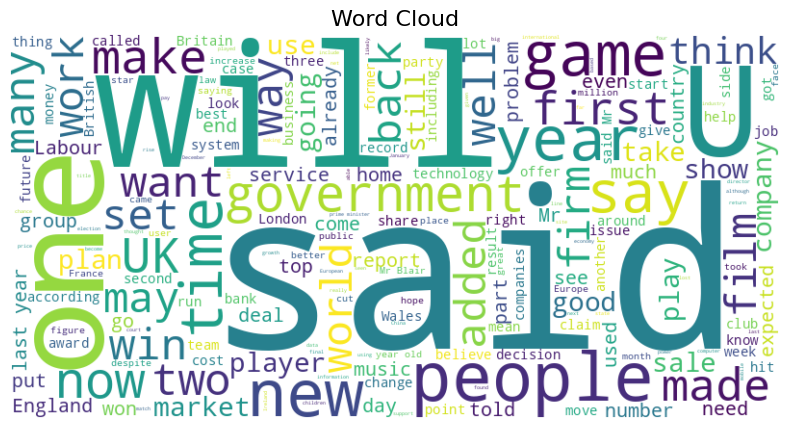

In [32]:
data = pd.read_csv(file_path)
text_data=" ".join(data['text'].dropna())
wordcloud=WordCloud(width=800,height=400,background_color='white').generate(text_data)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud',fontsize=16)
plt.show()